In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()
model=ChatOpenAI()

In [4]:
class Blog(TypedDict):
    title:str
    outline:str
    content:str

In [5]:
def create_outline(state:Blog)->Blog:
    #fetch title
    title=state['title']
    #call llm generate outline
    prompt=f'generate a detailed outline for a blog on the topic{title}'
    ans=model.invoke(prompt)
    #update state
    state['outline']=ans
    return state

In [6]:
def create_blog(state:Blog)->Blog:
    #fetch title,outline
    title=state['title']
    outline=state['outline']
    #call llm generate blog
    prompt=f'write a detailed blog on the title {title} based on the following outline {outline}'
    ans=model.invoke(prompt)
    #update state
    state['content']=ans
    return state

In [8]:
graph=StateGraph(Blog)
#nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
#edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)
#compile
workflow=graph.compile()

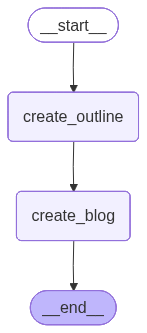

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [11]:
#execute graph
initial_state={'title':'Remarkable AI discoveries in last 5 years'}
final_state=workflow.invoke(initial_state)



In [12]:
print(final_state['outline'])

content="I. Introduction\n    A. Brief overview of AI technology\n    B. Explanation of the significance of AI discoveries in the past 5 years\nII. Breakthroughs in Natural Language Processing\n    A. Introduction of GPT-3\n    B. Advancements in language understanding and generation\n    C. Impact on various industries such as customer service and content creation\nIII. Progress in Computer Vision\n    A. Introduction of deep learning algorithms for image recognition\n    B. Improvements in object detection and image classification\n    C. Application in fields like healthcare, agriculture, and autonomous vehicles\nIV. Advancements in AI Ethics and Bias Mitigation\n    A. Introduction of fairness and transparency tools\n    B. Efforts to address biases in AI algorithms\n    C. Implications for societal impact and responsible AI development\nV. Breakthroughs in Reinforcement Learning\n    A. Introduction of DeepMind's AlphaGo\n    B. Progress in training AI agents to play complex games

In [13]:
print(final_state['content'])

content="AI technology has made significant strides in the past 5 years, with remarkable discoveries shaping various industries and transforming the way we interact with technology. In this blog, we will explore some of the key AI discoveries that have taken place in the last half-decade, ranging from breakthroughs in natural language processing to advancements in computer vision, AI ethics, reinforcement learning, and emerging trends in AI research.\n\nI. Introduction\n\nA. Brief overview of AI technology\n\nArtificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, especially computer systems. It involves learning, reasoning, problem-solving, perception, and language understanding. AI technology has the potential to automate tasks, improve decision-making, and provide valuable insights from vast amounts of data.\n\nB. Explanation of the significance of AI discoveries in the past 5 years\n\nAI discoveries in the past 5 years have significantly i